# Setup and Import

In [1]:
import os
import time
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
import tifffile as tiff
import gc
import rasterio
import tempfile
import sys
from skimage import feature, color
from skimage.filters import threshold_otsu
from skimage.morphology import dilation
from skimage.segmentation import expand_labels
from osgeo import gdal
from rasterio.shutil import copy

# Globals

## Constants and paths

Configuration for this step (step 4: adaptive Australian pipeline classification): which municipality (`procom`), index and flight year to process, the NoData conventions on input (`-20`) and output (`255`), Canny/dilation parameters, and which threshold from the step-3 CSV (`threshold_method`) is used to filter out fictitious edges around NoData pixels. Input/output paths are under `output/<procom>/`.

In [2]:
start_t = time.time()

random_state = 1234
input_nodata_value = -20   # NoData value used by step 1 for the index rasters
mask_nodata_value = 255    # NoData value for the output classification mask
seq_size = 100000000
dilation_pxls = 5 # 5 = 1m
pxl_area = 0.04 # in m^2; pixel size = 20 cm = 0.2 m
save_output_masks = True
index = 'NDVI_red'  # NDVI_red; ENDVI
procom = "059033"
city_dict = {'039014': 'Ravenna', 
             '065116': 'Salerno', 
             '031007': 'Gorizia', 
             '038008': 'Ferrara', 
             '051002': 'Arezzo', 
             '048017': 'Firenze',
             '010025': 'Genova',
             '037006': 'Bologna',
             '032006': 'Trieste',
             '015146': 'Milano',
             '063049': 'Napoli',
             '082053': 'Palermo',
             '001272': 'Torino',
             '092009': 'Cagliari',
             '058091': 'Roma',
             '027042': 'Venezia',
             '080063': 'Reggio Calabria',
             '087015': 'Catania',
             '083048': 'Messina',
             '059033': 'Ventotene_d1'}
city_name = city_dict[procom]
flight_year = '2022'
if (procom=='080063') & (flight_year == '2012'): #RC 2012 has different orthoimages: 50cm/pxl
   print('RC 2012; 50cm/pxl')
   pxl_area=0.25
evaluate_real_edges = True

# threshold_method selects which threshold (from the step-2 CSV) is used to build
# the KDE-based mask that removes fictitious Canny edges around NoData pixels:
#   'kde'     -> always use the KDE threshold
#   'kmeans'  -> always use the KMeans threshold
#   'auto'    -> use KDE, falling back to KMeans only if KDE threshold is <= 0
#                (i.e. no valid minimum was found in the density estimate)
threshold_method = 'auto'

# Input file produced by step 1 (crop + evaluate indices + mosaic), e.g.:
# C:\Users\UTENTE\Downloads\JOS_areeverdi\output\059033\Ventotene_d1-059033-NDVI_red-2022.tif
# This is the city-wide mosaic (step 1 deletes the intermediate per-tile files
# once the mosaic has been written), not a per-tile raster.
indices_file_name = city_name + '-' + procom + '-' + index + '-' + flight_year + '.tif'

# Summary stats CSV produced by step 3 (KDE + KMeans classification), holding
# the thresholds this step reads.
stat_file_name = city_name + '-' + procom + '-' + index + '-' + flight_year + '.csv'
show_images = False

# All inputs/outputs for this procom live under output/<procom>/
base_path = "C:/Users/UTENTE/Downloads/JOS_areeverdi/"
output_path = base_path + "output/" + procom + "/"

print('output_path: ', output_path)

output_path:  C:/Users/UTENTE/Downloads/JOS_areeverdi/output/059033/


In [3]:
print(index)
print(procom)
print(city_name)
print(flight_year)
print(indices_file_name)

NDVI_red
059033
Ventotene_d1
2022
Ventotene_d1-059033-NDVI_red-2022.tif


## Functions

I/O and export helpers:

- `read_geotiff` / `read_geotiff_as_ndarray`: open a GeoTIFF with GDAL, optionally as a plain numpy array.
- `memory_map`: fallback loader for very large, compressed rasters that don't fit comfortably in RAM.
- `show_variables`: debugging helper that lists in-memory variables sorted by size, to track down RAM usage.
- `load_mosaic`: generic loader that dispatches on file extension (`.tif`, `.npy`, `.npz`).
- `write_compressed_mask`: legacy writer (fixed NoData = 255), kept for reference but not used below.
- `write_compressed_mask_with_nodata`: the writer actually used to export the Australian classification mask — writes a compressed, tiled, Byte GeoTIFF block by block, declaring the given NoData value on the output band.

In [4]:

def read_geotiff(filename):
    ds = gdal.Open(filename)
    return ds

def read_geotiff_as_ndarray(filename):
    ds = gdal.Open(filename)
    band = ds.GetRasterBand(1)
    arr = band.ReadAsArray()
    return arr

def memory_map(src_path):
  dst_path = src_path.replace(".tif", "_uncompressed.tif")

  with tempfile.NamedTemporaryFile(suffix=".tif", delete=True) as tmp:
    with rasterio.open(src_path) as src:
        profile = src.profile
        profile.update(
            compress='none',
            tiled=False
        )
        copy(src, dst_path, **profile)   

  return tiff.memmap(dst_path)

def show_variables():
    # Get local and global variables and print their in-memory size, largest first
    # (debugging helper for tracking down RAM usage)
    variables_dict = {**globals(), **locals()}
    variables=[]
    for name, value in variables_dict.items():
        variables.append([name, sys.getsizeof(value)])
    print(pd.DataFrame(variables).sort_values(1,ascending=False))

def load_mosaic(path_to_mosaic, mosaic_file_name):
    ext = os.path.splitext(mosaic_file_name)[1][1:]
    print(ext)
    if ext == 'tif':
        print('Loading GeoTiff file')
        try:
            mosaic_array = read_geotiff_as_ndarray(os.path.join(path_to_mosaic, mosaic_file_name))
        except:
            mosaic_array = memory_map(os.path.join(path_to_mosaic, mosaic_file_name))
            
    elif ext == 'npy':
        print('Loading ndarray')
        mosaic_array = np.load(os.path.join(path_to_mosaic, mosaic_file_name))
    elif ext == 'npz':
        ds = np.load(os.path.join(path_to_mosaic, mosaic_file_name))
        mosaic_array = ds["array"]
        del ds
        gc.collect()

    return mosaic_array, ext

def write_compressed_mask(mask_file_name, mask_array, ds_mask):
    rows, cols = mask_array.shape
    driver = gdal.GetDriverByName("GTiff")
    ds = driver.Create(
        mask_file_name,
        cols,
        rows,
        1,
        gdal.GDT_Byte,
        options=[
            "COMPRESS=ZSTD",
            "ZSTD_LEVEL=9",
            "PREDICTOR=2",
            "TILED=YES",
            "BIGTIFF=YES",
            "BLOCKXSIZE=512",
            "BLOCKYSIZE=512",
            "NUM_THREADS=ALL_CPUS"
        ]
    )
    ds.SetProjection(ds_mask.GetProjection())
    ds.SetGeoTransform(ds_mask.GetGeoTransform())
    band = ds.GetRasterBand(1)
    band.SetNoDataValue(255)
    band.WriteArray(mask_array)
    band.FlushCache()
    ds = None
    print("GeoTIFF saved.")

def write_compressed_mask_with_nodata(mask_file_name, mask_array, ds_mask, mask_nodata_value=255):
    """
    Writes mask_array (already containing mask_nodata_value wherever the source
    pixel was NoData) as a compressed Byte GeoTIFF, reusing projection/geotransform
    from ds_mask (the source index raster). NoData handling is done upstream, on
    the numpy array itself, so this function just needs to declare the NoData
    value on the output band and write blockwise.
    """
    rows, cols = mask_array.shape

    driver = gdal.GetDriverByName("GTiff")
    ds = driver.Create(
        mask_file_name, 
        cols, 
        rows, 
        1, 
        gdal.GDT_Byte, 
        options=[
            "COMPRESS=ZSTD",
            "ZSTD_LEVEL=9",
            "PREDICTOR=2",
            "TILED=YES",
            "BIGTIFF=YES",
            "BLOCKXSIZE=512",
            "BLOCKYSIZE=512",
            "NUM_THREADS=ALL_CPUS"
        ]
    )
    
    # Copy georeferencing (projection + geotransform) from the source index raster
    ds.SetProjection(ds_mask.GetProjection())
    ds.SetGeoTransform(ds_mask.GetGeoTransform())
    
    band = ds.GetRasterBand(1)
    band.SetNoDataValue(mask_nodata_value)
    
    # Write block by block (512x512 pixels at a time) to keep peak memory low
    block_size = 512
    mask_array_u8 = mask_array.astype(np.uint8)

    for y in range(0, rows, block_size):
        y_size = min(block_size, rows - y)
        for x in range(0, cols, block_size):
            x_size = min(block_size, cols - x)
            out_block = mask_array_u8[y:y+y_size, x:x+x_size]
            band.WriteArray(out_block, x, y)

    # Close and flush to disk
    band.FlushCache()
    ds = None
    print("GeoTIFF successfully saved block by block: ", mask_file_name)

# Data

### Loading saved indices

Loads the index raster produced by step 1/2 (`indices_file_name`) into memory as a numpy array, then squeezes any singleton band dimension.

In [5]:
indices_values_array, ext = load_mosaic(output_path, indices_file_name)
print(indices_file_name)
print(indices_values_array.shape)
print(indices_values_array.dtype)

tif
Loading GeoTiff file


C:\Users\UTENTE\anaconda3\envs\geo\Lib\site-packages\osgeo\gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Ventotene_d1-059033-NDVI_red-2022.tif
(6526, 5309)
float32


In [6]:
if show_images:
    title = str(city_name) + ' -- ' + index + ' -- ' + flight_year
    tiff.imshow(np.where((indices_values_array >= -1.0) & (indices_values_array <= 1.0),indices_values_array,-1))
    plt.title(title)
    plt.show()

In [7]:
indices_values_array = np.squeeze(indices_values_array)
print(indices_values_array.shape)
print(indices_values_array.dtype)

(6526, 5309)
float32


### Load edge-mask threshold from the step-3 CSV report

For big rasters, re-running KDE/KMeans here would blow up available RAM, so the
threshold used to build the "real vegetation" mask (needed below to filter out
fictitious Canny edges around NoData pixels) is loaded from the summary CSV
produced by step 3, instead of being recomputed.

In [8]:
stat_file_df = pd.read_csv(os.path.join(output_path, stat_file_name),delimiter=";", index_col=0, decimal=',')
display(stat_file_df)

,city,method,fl. year,index,thres.,tot pix.,green pix.,green %,green m^2,green ha,elab. time
0,059033 Ventotene_d1,KDE,2022,NDVI_red,0.142857,9647428,4556477,47.229966,182259.08,18.225908,0.727198
1,059033 Ventotene_d1,KMeans (2 clusters),2022,NDVI_red,0.164751,9647428,4209685,43.635309,168387.40,16.838740,0.678105


In [9]:
# Pick the threshold to use for the edge mask, according to `threshold_method`
# ('kde', 'kmeans', or 'auto' = KDE with fallback to KMeans if KDE is invalid).
meths = stat_file_df['method'].values.tolist()
search_keys = [m.split()[0] for m in meths]
stat_file_df['search_keys'] = search_keys
print(search_keys)

def _get_threshold(method_key):
    thr = float(stat_file_df.loc[stat_file_df['search_keys'] == method_key, 'thres.'].values[0])
    n_tot = int(stat_file_df.loc[stat_file_df['search_keys'] == method_key, 'tot pix.'].values[0])
    return thr, n_tot

if threshold_method == 'kde':
    edge_threshold, tot_pxl = _get_threshold('KDE')
elif threshold_method == 'kmeans':
    edge_threshold, tot_pxl = _get_threshold('KMeans')
elif threshold_method == 'auto':
    edge_threshold, tot_pxl = _get_threshold('KDE')
    if edge_threshold <= 0.0:
        print('No minima in histogram; using KMeans threshold')
        edge_threshold, tot_pxl = _get_threshold('KMeans')
else:
    raise ValueError("threshold_method must be one of 'kde', 'kmeans', 'auto'")

print('threshold_method: ', threshold_method)
print('edge_threshold:   ', edge_threshold)
print('tot_pxl:          ', tot_pxl)

['KDE', 'KMeans']
threshold_method:  auto
edge_threshold:    0.1428571428571428
tot_pxl:           9647428


# The Australian pipeline
Follow the method illustrated [here](https://www.mdpi.com/2072-4292/8/5/386) , specifically the pipeline illustrated in section: _2.4.2. Adaptive Threshold Detection Using MNDWI, Canny Edge Filter, and Otsu Thresholding_ 

First step, Compute Index, is performed above and generates ```indices_flatten[i]``` datasets

#### Detect edges (Canny edge detector)
For Canny edge detection, see skimage documetation [here](https://scikit-image.org/docs/stable/api/skimage.feature.html#skimage.feature.canny) and a tutorial [here](https://scikit-image.org/docs/stable/auto_examples/edges/plot_canny.html)

<mark>Important:</mark> applying directly Canny alg. to image masked with threshold > KDE_min generates false edges: in fact, all the points around KDE_min generates edges since outside the mask the value is artificially set to -20.
In order to correctly select the edges generates by different shades of green, follow these points:

- perform Canny alg. on original image and obtain an edges mask;

- create the mask with KDE-thresholded pixels of original image;

- take the pixelwise AND of the two

in this way the fictional edges, generates by the -20 pixels, are eliminated.

##### Rule-of-thumb for Canny edge thresholds
For reference see [here](https://stackoverflow.com/questions/21324950/how-can-i-select-the-best-set-of-parameters-in-the-canny-edge-detection-algorith); or alternatively [here](https://towardsdatascience.com/canny-edge-detection-step-by-step-in-python-computer-vision-b49c3a2d8123) 

Canny edge detection: default values for scikit canny() work fine (e.g.: Enna)

For buffering, see skimage related argument [here](https://scikit-image.org/docs/stable/api/skimage.morphology.html#skimage.morphology.binary_dilation)

For Otsu threshold detection, see skimage related argument [here](https://scikit-image.org/docs/stable/auto_examples/segmentation/plot_thresholding.html); do:

- First: apply edge mask evaluated above: ```canny_red_array[buffer_red]```

- Second: cut the values outside loc1: ```indices_flatten[i]>loc1_threshold```

In [10]:
back = np.zeros((dilation_pxls*2+1,dilation_pxls*2+1), dtype=np.int8)
back[dilation_pxls,dilation_pxls] = 1
footprint = expand_labels(back, distance=dilation_pxls)
print(footprint)
print(footprint.shape)
print(footprint.dtype)
print()

[[0 0 0 0 0 1 0 0 0 0 0]
 [0 0 1 1 1 1 1 1 1 0 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1 1 1 1]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 1 1 1 1 1 1 1 1 1 0]
 [0 0 1 1 1 1 1 1 1 0 0]
 [0 0 0 0 0 1 0 0 0 0 0]]
(11, 11)
int8



In [11]:
aus_frac=0.01 #1.0 #0.1
x, y = indices_values_array.shape

# Tile sizes for the Canny/Otsu sampling loop below, capped to the raster's own
# dimensions: the original notebook used fixed 5000x10000 tiles sized for large
# city-wide mosaics, but for a single (much smaller) tile there is no need to
# tile at all -- a single iteration processes the whole raster.
tile_size_x = min(5000, x)
tile_size_y = min(10000, y)
print('raster shape:      ', (x, y))
print('tile_size_x/y:     ', (tile_size_x, tile_size_y))

k=1

np.random.seed(random_state)
otsu_final = np.empty([1]).astype(np.float16)
for i in range(0, x, tile_size_x):
    for j in range(0, y, tile_size_y):
        print('tile ' + str(k) + ': ' + str(i) + ' - ' + str(j))
        if np.any(indices_values_array[i:i+tile_size_x, j:j+tile_size_y]):
            print('Getting the correct tile from original image')
            otsu = indices_values_array[i:i+tile_size_x, j:j+tile_size_y]
            print(otsu.shape)
            print(otsu.dtype)
            print('Canny edge detection')
            if evaluate_real_edges:
                edges_mask = feature.canny(indices_values_array[i:i+tile_size_x, j:j+tile_size_y]) # Canny Edge Detection
                edge_mask = np.where((indices_values_array[i:i+tile_size_x, j:j+tile_size_y]>edge_threshold) & (indices_values_array[i:i+tile_size_x, j:j+tile_size_y] <= 1.0), True, False) # apply edge threshold
                edges = np.logical_and(edges_mask, edge_mask)
                print(edges_mask.shape)
                del edges_mask
                del edge_mask
                gc.collect()
            else:
                dilation_pxls = 1
                edges = feature.canny(np.where((indices_values_array[i:i+tile_size_x, j:j+tile_size_y] > edge_threshold) & (indices_values_array[i:i+tile_size_x, j:j+tile_size_y] <= 1.0), indices_values_array[i:i+tile_size_x, j:j+tile_size_y], input_nodata_value)) # Canny Edge Detection
            print(edges.shape)
            print('Buffering (dilation = ' + str(dilation_pxls) + ')')
            buffer = dilation(edges, footprint) # Buffer dilation
            del edges
            gc.collect()
            print(buffer.shape)
            print('Resampling with buffer mask')
            otsu = otsu[buffer[:otsu.shape[0], :otsu.shape[1]]]
            del buffer
            gc.collect()
            print(otsu.shape)
            print('Removing non-loc1 pixels')
            otsu = otsu[(otsu >= -1.0) & (otsu <= 1.0)]
            print(otsu.shape)
            if otsu.shape[0] > 0:
                #here: further random sampling to reduce RAM consumption
                sample_size = max(1, int(otsu.shape[0]*aus_frac))
                otsu = np.random.choice(otsu, size=sample_size, replace=False)
                print(otsu.shape)
                otsu_final = np.concatenate((otsu_final, otsu))
            else:
                print('No edge pixels left in this tile after masking; skipping sampling')
            print('otsu_final.shape=', otsu_final.shape)
            del otsu
            gc.collect()
        else:
            print('Empty tile')
            print(indices_values_array[i:i+tile_size_x, j:j+tile_size_y].shape)
        print()
        #show_variables()
        k+=1

#delete first element
otsu_final = otsu_final[1:]

raster shape:       (6526, 5309)
tile_size_x/y:      (5000, 5309)
tile 1: 0 - 0
Getting the correct tile from original image
(5000, 5309)
float32
Canny edge detection
(5000, 5309)
(5000, 5309)
Buffering (dilation = 5)
(5000, 5309)
Resampling with buffer mask
(4276335,)
Removing non-loc1 pixels
(4210627,)
(42106,)
otsu_final.shape= (42107,)

tile 2: 5000 - 0
Getting the correct tile from original image
(1526, 5309)
float32
Canny edge detection
(1526, 5309)
(1526, 5309)
Buffering (dilation = 5)
(1526, 5309)
Resampling with buffer mask
(1254383,)
Removing non-loc1 pixels
(1231618,)
(12316,)
otsu_final.shape= (54423,)



In [12]:
otsu_threshold = threshold_otsu(otsu_final)
print(otsu_threshold)

0.22608264


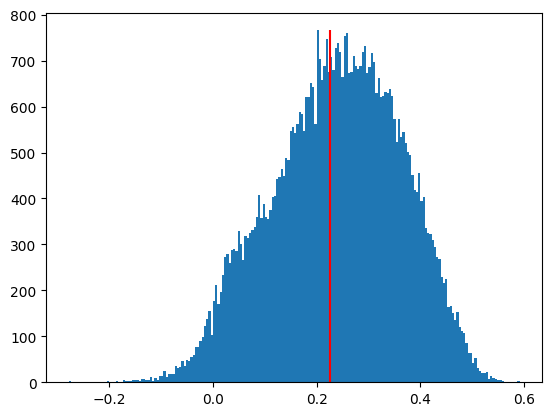

In [13]:
n, _, _ = plt.hist(otsu_final, bins=200)
plt.vlines(otsu_threshold, colors="red", ymin=0, ymax=max(n))
plt.show()

In [14]:
#memory cleaning
del otsu_final
gc.collect()

6

In [15]:
indices_values_array = np.reshape(indices_values_array, (x*y))
tot_seq = indices_values_array.shape[0]
print(indices_values_array.shape)
print(indices_values_array.dtype)

(34646534,)
float32


In [16]:
# Final classification: 1 = vegetation, 0 = non-vegetation, mask_nodata_value (255)
# wherever the input pixel was NoData (input_nodata_value = -20) -- this NoData
# handling is done explicitly here (not just relied upon downstream in the writer),
# to guarantee the mask is correct even if the source raster's NoData flag is unset.
k=1
n_pxl = 0
for i in range(0, tot_seq, seq_size):
    print('tile ' + str(k) + ': ' + str(i))
    chunk = indices_values_array[i:i+seq_size]
    if np.any(chunk):
        valid = (chunk != input_nodata_value)
        classified = np.where((chunk >= otsu_threshold) & (chunk <= 1.0), 1, 0).astype(np.int16)
        classified[~valid] = mask_nodata_value
        indices_values_array[i:i+seq_size] = classified
        n_pxl += np.sum(classified == 1, dtype=np.int64)
        print(n_pxl)
        del valid, classified
        gc.collect()
    else:
        print('Empty tile')
        print(chunk.shape)
    k+=1

indices_values_array = np.reshape(indices_values_array,(x,y,-1))
indices_values_array = np.squeeze(indices_values_array, axis=2)
print(indices_values_array.shape)
print(indices_values_array.dtype)

tile 1: 0
3189243
(6526, 5309)
float32


# Stats

Builds a one-row summary (method = "Australian") with the Otsu threshold used, total valid pixels, classified vegetation pixels/percentage/area (m² and ha), and total elapsed time for this step. This row (`data_fr`) is appended to the step-3 CSV in the Export section below.

In [17]:
end_t = time.time()
e_t = end_t - start_t
print('Total time: ', e_t)

methods = ['Australian (real edg. = ' + str(evaluate_real_edges) + '; dil. = ' + str(dilation_pxls) + ')']
perc = n_pxl/tot_pxl*100
m_2 = n_pxl * pxl_area
km_2 = m_2 * 1e-6
ha = m_2 * 1e-4

data_dict = {'city': [procom + ' ' + city_name],
             'method': methods, 
             'fl. year': flight_year,
             'index': index, 
             'thres.': [otsu_threshold], 
             'tot pix.': [tot_pxl], 
             'green pix.': [n_pxl], 
             'green %': [perc], 
             'green m^2': [m_2], 
             'green ha': [ha],
             'elab. time': [e_t]}
data_fr = pd.DataFrame(data_dict)
display(data_fr)

Total time:  26.60670042037964


,city,method,fl. year,index,thres.,tot pix.,green pix.,green %,green m^2,green ha,elab. time
0,059033 Ventotene_d1,Australian (real edg. = True; dil. = 5),2022,NDVI_red,0.226083,9647428,3189243,33.057961,127569.72,12.756972,26.6067


# Export

Writes the outputs of this step, all into `output_path` (`output/<procom>/`):

- `<city_name>-<procom>-<index>-<flight_year>--Australian_mask.tif` — binary vegetation mask from the Otsu threshold (only if `save_output_masks` is `True`). Byte raster: `0` = non-vegetation, `1` = vegetation, `255` = NoData, reusing the projection/geotransform of the source index raster.
- `<city_name>-<procom>-<index>-<flight_year>.csv` — summary stats (always written): this method's row is appended to the existing step-3 CSV (KDE/KMeans) if found, otherwise a new CSV is created with just this row.

In [18]:
if save_output_masks:
    ds_1 = read_geotiff(os.path.join(output_path, indices_file_name))
    print(ds_1.GetProjection())
    print(ds_1.GetGeoTransform())
    print(indices_values_array.shape)

PROJCS["RDN2008 / UTM zone 33N",GEOGCS["RDN2008",DATUM["Rete_Dinamica_Nazionale_2008",SPHEROID["GRS 1980",6378137,298.257222101,AUTHORITY["EPSG","7019"]],AUTHORITY["EPSG","1132"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","6706"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",15],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","7792"]]
(366955.1456853751, 0.2, 0.0, 4518024.42108661, 0.0, -0.2)
(6526, 5309)


In [19]:
if save_output_masks:
    n = city_name + '-' + procom + '-' + index + '-' + flight_year + '--Australian_mask.tif'
    write_compressed_mask_with_nodata(os.path.join(output_path, n), indices_values_array, ds_1, mask_nodata_value)

# CSV with the summary stats -- always written, independently of save_output_masks,
# matching the format of the reference CSV (';'-separated, comma as decimal separator).
# Appends this method's row to the existing step-3 CSV (KDE/KMeans) if present,
# otherwise writes a new file with just this row.
csv_path = os.path.join(output_path, stat_file_name)
if os.path.exists(csv_path):
    existing_df = pd.read_csv(csv_path, delimiter=';', index_col=0, decimal=',')
    existing_df = existing_df.drop(columns=['search_keys'], errors='ignore')
    combined_df = pd.concat([existing_df, data_fr], ignore_index=True)
else:
    combined_df = data_fr

combined_df.to_csv(csv_path, sep=';', decimal=',', index=True)
print('CSV saved: ', csv_path)

GeoTIFF successfully saved block by block:  C:/Users/UTENTE/Downloads/JOS_areeverdi/output/059033/Ventotene_d1-059033-NDVI_red-2022--Australian_mask.tif
CSV saved:  C:/Users/UTENTE/Downloads/JOS_areeverdi/output/059033/Ventotene_d1-059033-NDVI_red-2022.csv
